### EX: Random Forest Generalization

In this exercise, we will explore the bias-variance tradeoff by comparing a single, overfitted decision tree to an ensemble Random Forest. You will execute the following steps:

* **Generate Data:** Create a highly dimensional dataset representing complex multi-domain mission metrics (15 different features).
* **Train Decision Tree:** Train a single Decision Tree with unlimited depth, allowing it to perfectly memorize the training data (high variance).
* **Train Random Forest:** Train a Random Forest with restricted depth and multiple trees (bagging) to prevent overfitting.
* **Plot Comparison:** Generate a bar chart comparing the training and testing accuracies of both models to visualize which algorithm generalizes better to unseen missions.


In [1]:
#Only run this cell after selecting your kernel
!pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas

Sample Multi-Domain Mission Data:
   Mission_Metric_1  Mission_Metric_2  Mission_Metric_3  Mission_Metric_4
0         -0.492065         -0.976693         -0.307329          0.466067
1         -0.112596          0.952160         -0.835442         -1.099736
2         -1.148413         -1.563802         -1.223709          0.298535
3          1.230180         -0.303114          1.859714          1.824913
4         -1.878762          0.242066         -1.093121          1.448445
...



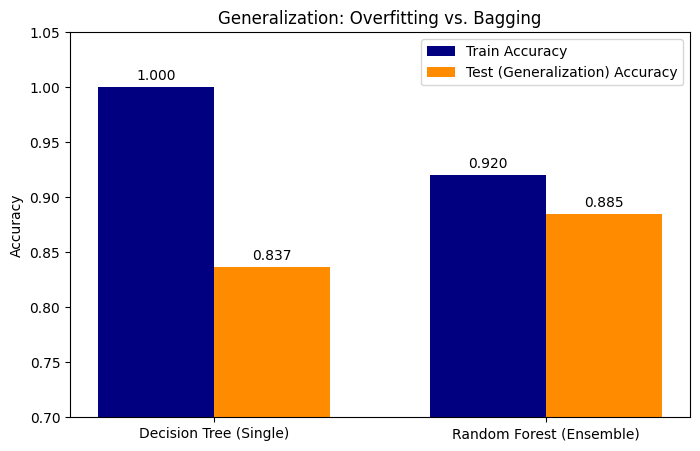

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Generate Complex Mission Data (15 features like cloud cover, fuel, intel confidence)
X_miss, y_miss = make_classification(n_samples=2000, n_features=15, n_informative=5, random_state=42)

df_mission = pd.DataFrame(X_miss, columns=[f'Mission_Metric_{i}' for i in range(1, 16)])
df_mission['Mission_Success'] = y_miss
print("Sample Multi-Domain Mission Data:")
print(df_mission.iloc[:, :4].head()) # Show first 4 metrics for readability
print("...\n")

# Split the data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_miss, y_miss, test_size=0.3, random_state=42)

# 2. Train Models
dt = DecisionTreeClassifier(max_depth=None, random_state=42) # Unlimited depth memorizes data
dt.fit(X_train_m, y_train_m)
dt_train_acc = accuracy_score(y_train_m, dt.predict(X_train_m))
dt_test_acc = accuracy_score(y_test_m, dt.predict(X_test_m))

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_m, y_train_m)
rf_train_acc = accuracy_score(y_train_m, rf.predict(X_train_m))
rf_test_acc = accuracy_score(y_test_m, rf.predict(X_test_m))

# 3. Plot the Bias-Variance Gap
labels = ['Decision Tree (Single)', 'Random Forest (Ensemble)']
train_scores = [dt_train_acc, rf_train_acc]
test_scores = [dt_test_acc, rf_test_acc]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='navy')
rects2 = ax.bar(x + width/2, test_scores, width, label='Test (Generalization) Accuracy', color='darkorange')

ax.set_ylabel('Accuracy')
ax.set_title('Generalization: Overfitting vs. Bagging')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0.7, 1.05])
ax.legend()

# Add labels on top of bars
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.show()


### Interpreting the Results

The bar chart beautifully illustrates the **Bias-Variance Tradeoff**.

Look at the **Decision Tree**. Its dark blue training bar is a perfect 1.000 (100%). It has zero bias on the training set because it grew deep enough to memorize every single mission in history. However, its orange testing bar drops drastically. This is high variance—it memorized the *noise* of past missions rather than the *rules* of warfare.

Now look at the **Random Forest**. We forced its trees to be shallow (max_depth=5), which reduced its training accuracy slightly. But by averaging 100 of these "weaker" trees together, the testing accuracy out-performed the single tree. The Random Forest sacrificed a tiny bit of training perfection to achieve superior generalization. For a commanding officer relying on AI for future mission planning, the Random Forest is the only viable option.